# Les niveaux d'eau de la bonne

In [60]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from functools import reduce
import tqdm


Récupération des débits instantanés (5 derniers jours)...
✅ 1377 mesures instantanées récupérées.

Récupération des débits moyens journaliers (3 dernières années)...
✅ 1083 mesures journalières récupérées.


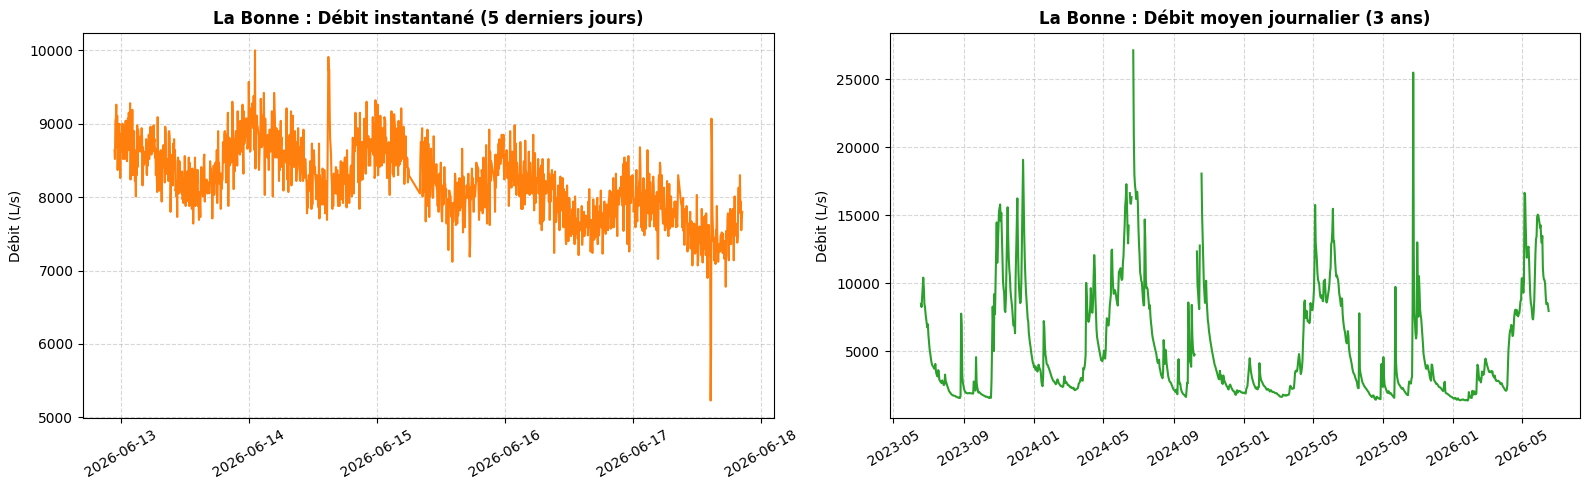

In [112]:
# Configuration
station_code = "W231401001"
now = datetime.now()

# -------------------------------------------------------------------
# 1. DÉBIT INSTANTANÉ (5 DERNIERS JOURS) - Endpoint: observations_tr
# -------------------------------------------------------------------
url_tr = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/observations_tr"
date_5j = (now - timedelta(days=5)).strftime('%Y-%m-%dT%H:%M:%SZ')

params_tr = {
    "code_entite": station_code,
    "grandeur_hydro": "Q",
    "date_fin_obs":  (now).strftime('%Y-%m-%dT%H:%M:%SZ'),
    "date_debut_obs": date_5j,
    "size": 10000,
    "sort": "asc"
}

print("Récupération des débits instantanés (5 derniers jours)...")
resp_tr = requests.get(url_tr, params=params_tr)

if resp_tr.status_code in [200, 206]:
    df_inst = pd.DataFrame(resp_tr.json()['data'])
    df_inst = df_inst[['date_obs', 'resultat_obs']].copy()
    df_inst['date_obs'] = pd.to_datetime(df_inst['date_obs'])
    df_inst['resultat_obs'] = pd.to_numeric(df_inst['resultat_obs'])
    print(f"✅ {len(df_inst)} mesures instantanées récupérées.")
else:
    print(f"❌ Erreur API TR : {resp_tr.status_code}")

# -------------------------------------------------------------------
# 2. DÉBIT MOYEN JOURNALIER QmnJ (3 DERNIÈRES ANNÉES) - Endpoint: obs_elab
# -------------------------------------------------------------------
url_elab = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
date_3ans = (now - timedelta(days=3*365)).strftime('%Y-%m-%d')

params_elab = {
    "code_entite": station_code,
    "grandeur_hydro_elab": "QmnJ", 
    "date_debut_obs_elab": date_3ans, # Paramètre corrigé pour la V2
    "size": 2000,                  
    "sort": "asc"
}

print("\nRécupération des débits moyens journaliers (3 dernières années)...")
resp_elab = requests.get(url_elab, params=params_elab)

if resp_elab.status_code in [200, 206]:
    df_moyen = pd.DataFrame(resp_elab.json()['data'])
    
    # CORRECTION : Utilisation des champs spécifiques à l'endpoint obs_elab
    df_moyen = df_moyen[['date_obs_elab', 'resultat_obs_elab']].copy()
    
    # Renommage pour uniformiser tes variables d'analyse
    df_moyen = df_moyen.rename(columns={
        'date_obs_elab': 'date_obs',
        'resultat_obs_elab': 'resultat_obs'
    })
    
    df_moyen['date_obs'] = pd.to_datetime(df_moyen['date_obs'])
    df_moyen['resultat_obs'] = pd.to_numeric(df_moyen['resultat_obs'])
    print(f"✅ {len(df_moyen)} mesures journalières récupérées.")
else:
    print(f"❌ Erreur API Élaborée : {resp_elab.status_code}")
    print(resp_elab.text)

# -------------------------------------------------------------------
# 3. VISUALISATION DES DEUX COURBES
# -------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if 'df_inst' in locals() and not df_inst.empty:
    ax1.plot(df_inst['date_obs'], df_inst['resultat_obs'], color='#ff7f0e')
    ax1.set_title("La Bonne : Débit instantané (5 derniers jours)", fontweight='bold')
    ax1.set_ylabel("Débit (L/s)")
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(True, linestyle='--', alpha=0.5)

if 'df_moyen' in locals() and not df_moyen.empty:
    ax2.plot(df_moyen['date_obs'], df_moyen['resultat_obs'], color='#2ca02c')
    ax2.set_title("La Bonne : Débit moyen journalier (3 ans)", fontweight='bold')
    ax2.set_ylabel("Débit (L/s)")
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# La météo

Récupération des données météo et neige historiques...
✅ 1096 jours de données météo récupérés.


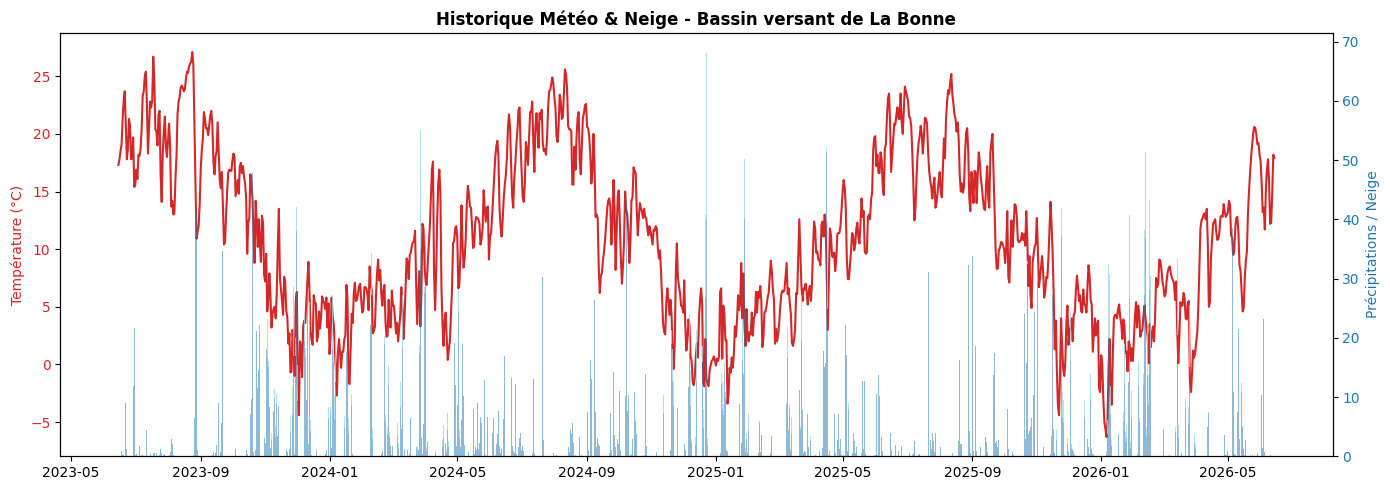

In [4]:
now = datetime.now()
date_fin = now.strftime('%Y-%m-%d')
date_debut = (now - timedelta(days=3*365)).strftime('%Y-%m-%d')

# Coordonnées géographiques de la station de La Bonne
lat, lon = 44.9003, 5.9444

# Endpoint de l'API Historique d'Open-Meteo
url_meteo = "https://archive-api.open-meteo.com/v1/archive"

params_meteo = {
    "latitude": lat,
    "longitude": lon,
    "start_date": date_debut,
    "end_date": date_fin,
    # On demande les cumuls journaliers de pluie, neige et la température moyenne
    "daily": ["temperature_2m_mean", "precipitation_sum", "snowfall_sum"],
    "timezone": "Europe/Paris"
}

print("Récupération des données météo et neige historiques...")
resp_meteo = requests.get(url_meteo, params=params_meteo)

if resp_meteo.status_code == 200:
    data_meteo = resp_meteo.json()
    
    # Extraction des données journalières
    daily_data = data_meteo['daily']
    
    # Création du DataFrame
    df_meteo = pd.DataFrame({
        'date': pd.to_datetime(daily_data['time']),
        'temperature_moyenne': daily_data['temperature_2m_mean'],
        'precipitations_cumul_mm': daily_data['precipitation_sum'],
        'chute_neige_cumul_cm': daily_data['snowfall_sum'] # Équivalent en eau/neige
    })
    
    print(f"✅ {len(df_meteo)} jours de données météo récupérés.")
    
    # Petit aperçu graphique
    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Courbe des températures
    ax1.plot(df_meteo['date'], df_meteo['temperature_moyenne'], color='#d62728', label='Température moyenne (°C)')
    ax1.set_ylabel('Température (°C)', color='#d62728')
    ax1.tick_params(axis='y', labelcolor='#d62728')

    # Axe secondaire pour les précipitations (pluie + neige)
    ax2 = ax1.twinx()
    ax2.bar(df_meteo['date'], df_meteo['precipitations_cumul_mm'], color='#1f77b4', alpha=0.5, label='Pluie (mm)')
    ax2.bar(df_meteo['date'], df_meteo['chute_neige_cumul_cm'], bottom=df_meteo['precipitations_cumul_mm'], color='#9edae5', alpha=0.8, label='Neige (cm)')
    ax2.set_ylabel('Précipitations / Neige', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

    plt.title("Historique Météo & Neige - Bassin versant de La Bonne", fontweight='bold')
    fig.tight_layout()
    plt.show()

else:
    print(f"Erreur API Open-Meteo : {resp_meteo.status_code}")

In [9]:

# 1. Définition du bassin versant (Centre + N, S, E, O)
# Coordonnées géographiques de la station de La Bonne
lat_center, lon_center = 44.9003, 5.9444

# Distance en km pour le quadrillage
distance_km = 30

# Conversion des distances en degrés (approximation)
degree_lat = distance_km / 111  # 1 degré latitude ≈ 111 km
degree_lon = distance_km / (111 * np.cos(np.radians(lat_center)))  # 1 degré longitude ≈ 111 * cos(latitude) km

# Créer le quadrillage
lats = [lat_center - degree_lat, lat_center + degree_lat, lat_center + degree_lat, lat_center - degree_lat, lat_center - degree_lat]
lons = [lon_center - degree_lon, lon_center - degree_lon, lon_center + degree_lon, lon_center + degree_lon, lon_center - degree_lon]


# CORRECTION 1 : Open-Meteo veut une seule chaîne séparée par des virgules
lats_str = ",".join(map(str, lats))
lons_str = ",".join(map(str, lons))

url_meteo = "https://archive-api.open-meteo.com/v1/archive"

# CORRECTION 2 : On bascule tout sur 'hourly'
params_meteo = {
    "latitude": lats_str,
    "longitude": lons_str,
    "start_date": date_3ans, 
    "end_date": date_fin,    
    "hourly": ["temperature_2m", "precipitation", "snow_depth"],
    "timezone": "Europe/Paris"
}

print("Récupération de la météo horaire maillée...")
resp_meteo = requests.get(url_meteo, params=params_meteo)

if resp_meteo.status_code == 200:
    donnees_points = resp_meteo.json()
    liste_dfs = []
    
    for i, data_point in enumerate(donnees_points):
        # On crée le tableau horaire pour le point i
        df_temp = pd.DataFrame({
            'date': pd.to_datetime(data_point['hourly']['time']),
            f'temp_pt{i}': data_point['hourly']['temperature_2m'],
            f'precip_pt{i}': data_point['hourly']['precipitation'],
            f'neige_sol_pt{i}': data_point['hourly']['snow_depth'] # En mètres !
        })
        
        # CORRECTION 3 : Transformation du pas horaire au pas journalier (Resampling)
        # Moyenne pour la temp, somme pour la pluie, moyenne pour la neige au sol
        df_journalier = df_temp.set_index('date').resample('D').agg({
            f'temp_pt{i}': 'mean',
            f'precip_pt{i}': 'sum',
            f'neige_sol_pt{i}': 'mean' 
        }).reset_index()
        
        liste_dfs.append(df_journalier)
    
    # Fusion des 5 tableaux (les 5 points géographiques) sur la date
    df_bassin = reduce(lambda left, right: pd.merge(left, right, on=['date'], how='outer'), liste_dfs)
    
    # 2. CALCUL DES MOYENNES GLOBALES SUR LE BASSIN VERSANT
    cols_temp = [col for col in df_bassin.columns if 'temp_pt' in col]
    df_bassin['temperature_bassin'] = df_bassin[cols_temp].mean(axis=1)
    
    cols_precip = [col for col in df_bassin.columns if 'precip_pt' in col]
    df_bassin['precipitations_bassin'] = df_bassin[cols_precip].mean(axis=1)
    
    cols_neige = [col for col in df_bassin.columns if 'neige_sol_pt' in col]
    df_bassin['hauteur_neige_bassin'] = df_bassin[cols_neige].mean(axis=1)
    
    # Le DataFrame final, propre et prêt pour le ML
    df_meteo_clean = df_bassin[['date', 'temperature_bassin', 'precipitations_bassin', 'hauteur_neige_bassin']].copy()
    
    print(f"✅ Météo journalière moyennée sur {len(lats)} points récupérée avec succès !")
    print(df_meteo_clean.head())

else:
    print(f"❌ Erreur API : {resp_meteo.status_code}")
    print(resp_meteo.text)

Récupération de la météo horaire maillée...
✅ Météo journalière moyennée sur 5 points récupérée avec succès !
        date  temperature_bassin  precipitations_bassin  hauteur_neige_bassin
0 2023-06-15           12.619167                   1.10                   0.0
1 2023-06-16           13.132500                   0.28                   0.0
2 2023-06-17           14.649167                   0.00                   0.0
3 2023-06-18           14.866667                   3.56                   0.0
4 2023-06-19           16.163333                   2.06                   0.0


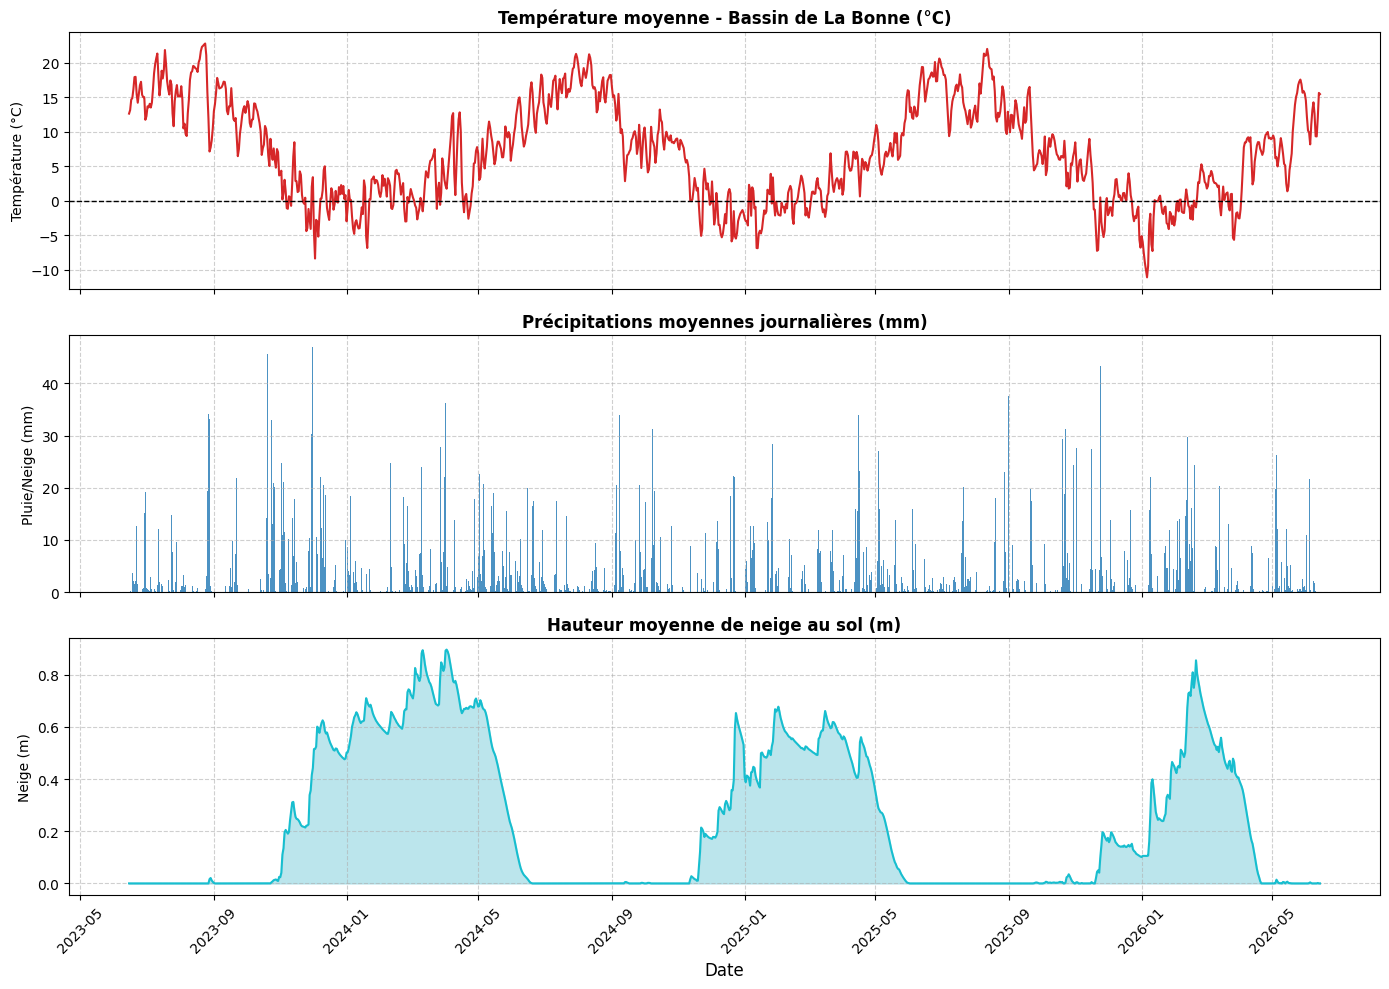

In [10]:
# Création d'une figure avec 3 sous-graphiques empilés
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# -------------------------------------------------------------------
# 1. Température (Courbe rouge)
# -------------------------------------------------------------------
ax1.plot(df_meteo_clean['date'], df_meteo_clean['temperature_bassin'], color='#d62728', linewidth=1.5)
ax1.set_title("Température moyenne - Bassin de La Bonne (°C)", fontweight='bold', fontsize=12)
ax1.set_ylabel("Température (°C)")
ax1.grid(True, linestyle='--', alpha=0.6)
# Ajout d'une ligne horizontale à 0°C pour bien voir le point de gel/fonte
ax1.axhline(0, color='black', linewidth=1, linestyle='--')

# -------------------------------------------------------------------
# 2. Précipitations (Barres bleues)
# -------------------------------------------------------------------
ax2.bar(df_meteo_clean['date'], df_meteo_clean['precipitations_bassin'], color='#1f77b4', alpha=0.8)
ax2.set_title("Précipitations moyennes journalières (mm)", fontweight='bold', fontsize=12)
ax2.set_ylabel("Pluie/Neige (mm)")
ax2.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# 3. Neige au sol (Aire remplie cyan)
# -------------------------------------------------------------------
ax3.fill_between(df_meteo_clean['date'], df_meteo_clean['hauteur_neige_bassin'], color='#9edae5', alpha=0.7)
ax3.plot(df_meteo_clean['date'], df_meteo_clean['hauteur_neige_bassin'], color='#17becf', linewidth=1.5)
ax3.set_title("Hauteur moyenne de neige au sol (m)", fontweight='bold', fontsize=12)
ax3.set_ylabel("Neige (m)")
ax3.set_xlabel("Date", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Finitions
# -------------------------------------------------------------------
plt.xticks(rotation=45)
plt.tight_layout() # Évite que les labels ne se chevauchent
plt.show()

1/3 Téléchargement des données rivière...
2/3 Téléchargement des données météo...
3/3 Alignement et fusion...

DataFrame prêt : (31, 5) (Pandas DataFrame)


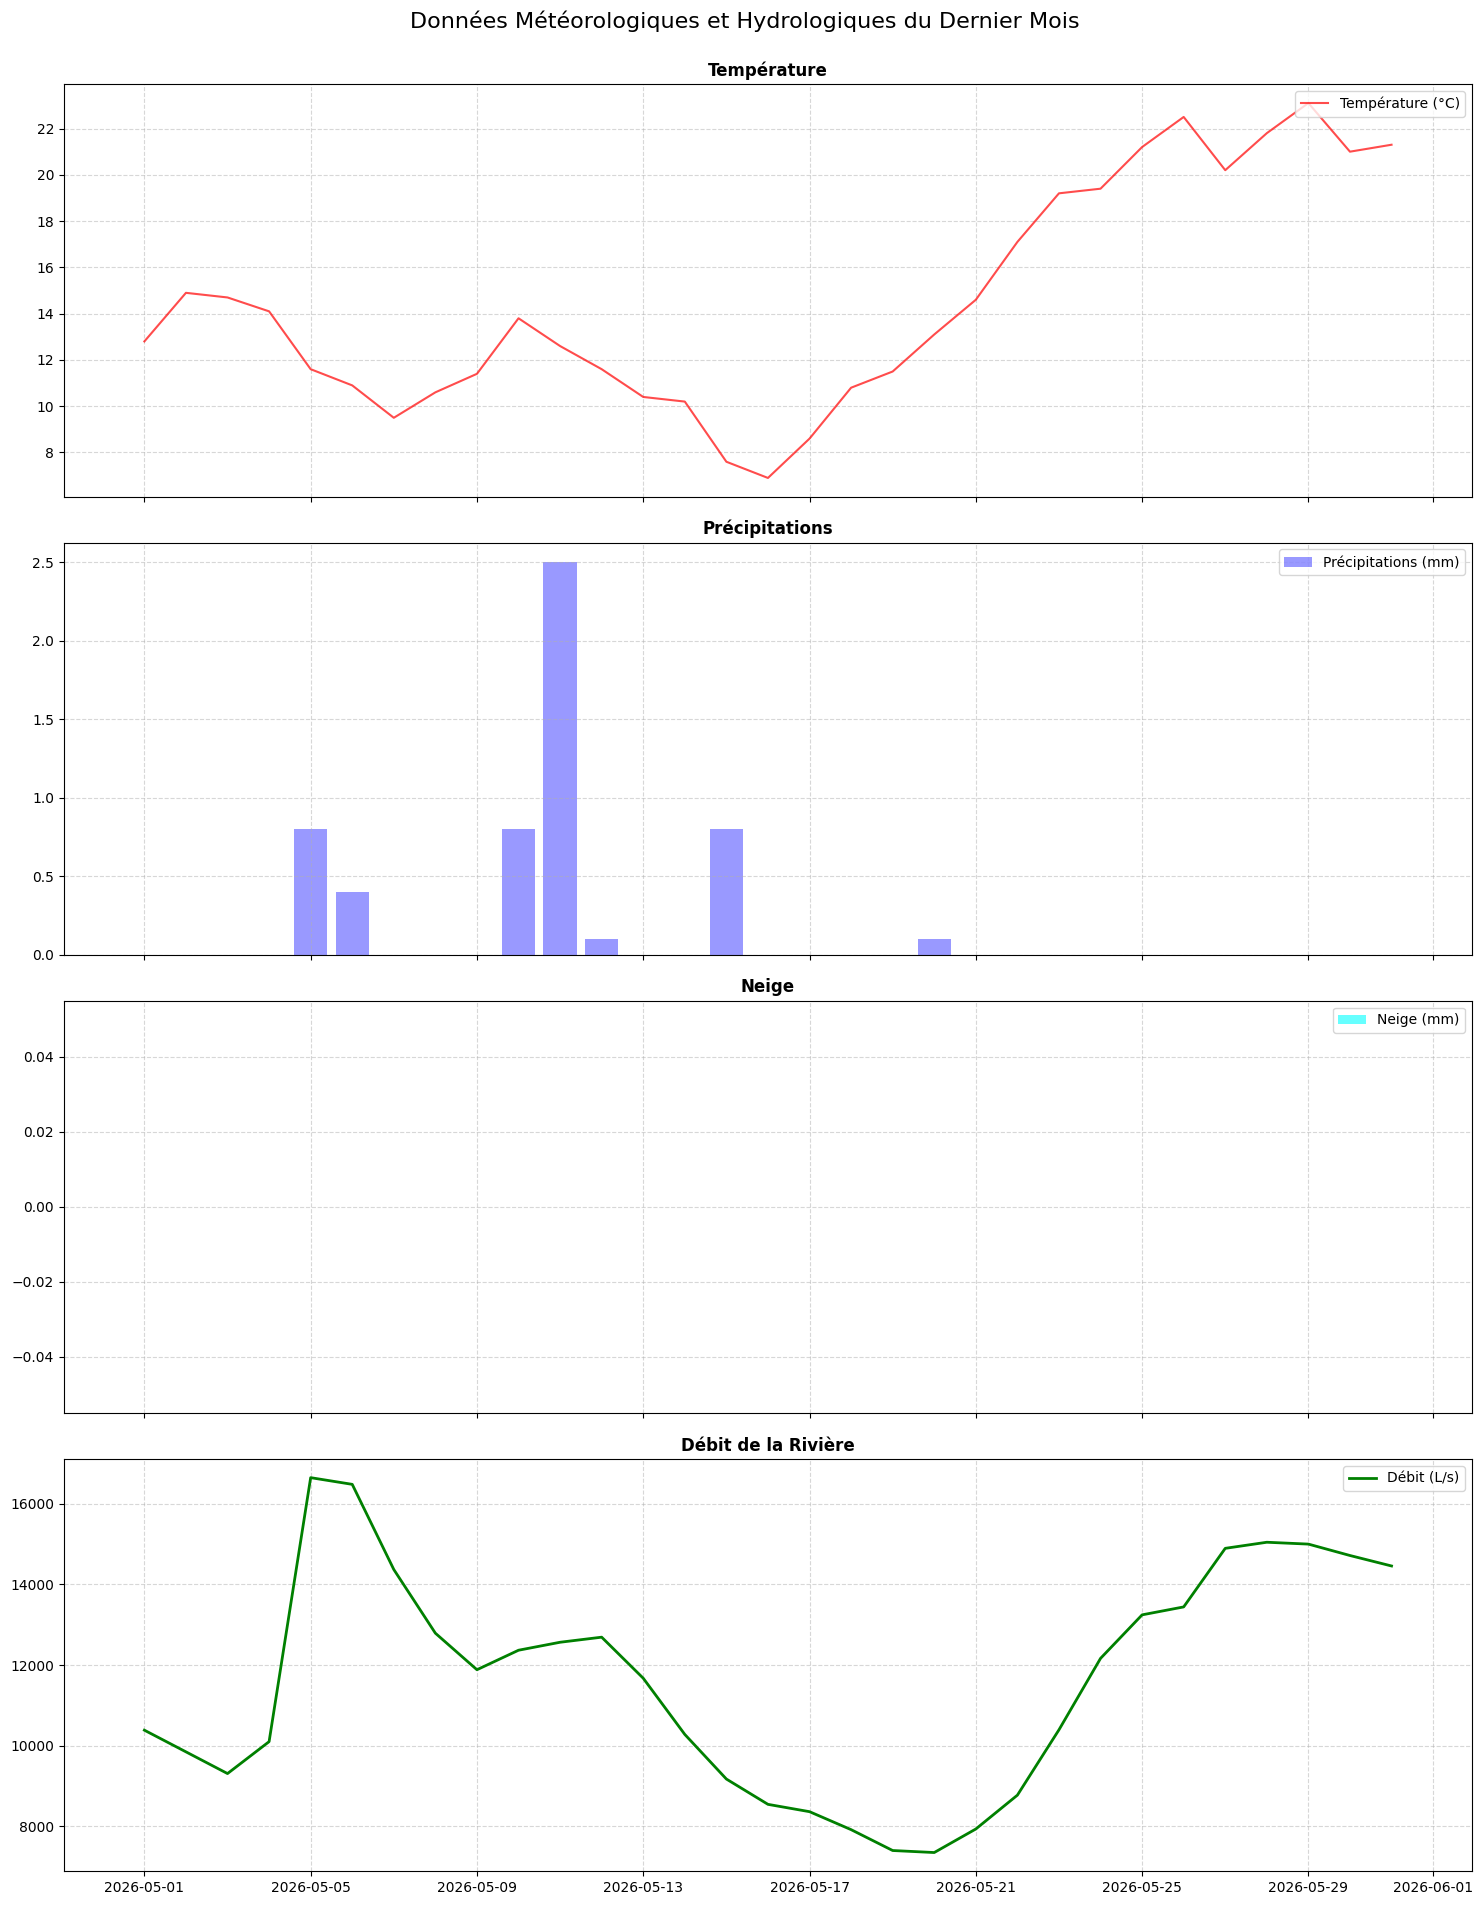

In [140]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. FONCTIONS DE COLLECTE (Retournent des Pandas DataFrame pour la sécurité)
# ==========================================

def fetch_river_data(station_code, start_date, end_date):
    """Récupère le débit moyen journalier (QmnJ)"""
    url = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
    params = {
        "code_entite": station_code,
        "grandeur_hydro_elab": "QmnJ",
        "date_debut_obs_elab": start_date,
        "date_fin_obs_elab": end_date,
        "size": 5000,
        "sort": "asc"
    }
    resp = requests.get(url, params=params)
    if resp.status_code in [200, 206]:
        data = resp.json().get('data', [])
        df = pd.DataFrame(data)[['date_obs_elab', 'resultat_obs_elab']]
        df = df.rename(columns={'date_obs_elab': 'date', 'resultat_obs_elab': 'debit_L_s'})
        df['date'] = pd.to_datetime(df['date'])
        return df
    else:
        raise Exception(f"Erreur Hub'Eau : {resp.status_code}")

def fetch_weather_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ["temperature_2m", "precipitation", "snow_depth"],
        "timezone": "Europe/Paris"
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()['hourly']
        df = pd.DataFrame({
            'date': pd.to_datetime(data['time']),
            'temperature_C': data['temperature_2m'],
            'precip_mm': data['precipitation'],
            'neige_m': data['snow_depth']
        })
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")



# ==========================================
# 2. Fonction D'Assemblage (Retourne un seul DataFrame)
# ==========================================

def assemble_dataset(station_code, lat, lon, start_date, end_date):
    """
    Télécharge, aligne et nettoie les données.
    Retourne un seul DataFrame avec toutes les colonnes nécessaires.
    """
    print("1/3 Téléchargement des données rivière...")
    df_eau = fetch_river_data(station_code, start_date, end_date)
    
    print("2/3 Téléchargement des données météo...")
    df_meteo = fetch_weather_data(lat, lon, start_date, end_date)
    
    print("3/3 Alignement et fusion...")
    # Jointure stricte sur la date : on ne garde que les jours où on a TOUTES les infos
    df_merged = pd.merge(df_meteo, df_eau, on='date', how='inner').dropna()
    
    return df_merged

# ==========================================
# 3. Fonction pour obtenir la plage de dates du dernier mois
# ==========================================

from datetime import datetime, timedelta

def get_last_month_dates():
    today = datetime.today()
    first_day_of_current_month = datetime(today.year, today.month, 1)
    last_day_of_previous_month = first_day_of_current_month - timedelta(days=1)
    first_day_of_previous_month = datetime(last_day_of_previous_month.year, last_day_of_previous_month.month, 1)
    
    start_date = first_day_of_previous_month.strftime('%Y-%m-%d')
    end_date = last_day_of_previous_month.strftime('%Y-%m-%d')
    
    return start_date, end_date

# ==========================================
# 4. Exemple D'Utilisation et Visualisation
# ==========================================

def visualize_last_month_data(station_code, lat, lon):
    # Obtenir les dates du dernier mois
    start_date, end_date = get_last_month_dates()
    
    # Générer le DataFrame
    df_dataset = assemble_dataset(station_code, lat, lon, start_date, end_date)
    
    print(f"\nDataFrame prêt : {df_dataset.shape} (Pandas DataFrame)")
    
    # Création des graphiques
    fig, axs = plt.subplots(4, 1, figsize=(15, 20), sharex=True)
    plt.suptitle('Données Météorologiques et Hydrologiques du Dernier Mois', fontsize=16)

    # Graphique Température
    axs[0].plot(df_dataset['date'], df_dataset['temperature_C'], color='red', label="Température (°C)", alpha=0.7)
    axs[0].set_title("Température", fontweight='bold')
    axs[0].legend(loc="upper right")
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # Graphique Précipitations
    axs[1].bar(df_dataset['date'], df_dataset['precip_mm'], color='blue', label="Précipitations (mm)", alpha=0.4)
    axs[1].set_title("Précipitations", fontweight='bold')
    axs[1].legend(loc="upper right")
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Graphique Neige
    axs[2].bar(df_dataset['date'], df_dataset['neige_m'] * 1000, color='cyan', label="Neige (mm)", alpha=0.6)
    axs[2].set_title("Neige", fontweight='bold')
    axs[2].legend(loc="upper right")
    axs[2].grid(True, linestyle='--', alpha=0.5)

    # Graphique Débit
    axs[3].plot(df_dataset['date'], df_dataset['debit_L_s'], color='green', label="Débit (L/s)", linewidth=2)
    axs[3].set_title("Débit de la Rivière", fontweight='bold')
    axs[3].legend(loc="upper right")
    axs[3].grid(True, linestyle='--', alpha=0.5)

    # Ajustement pour éviter le chevauchement des étiquettes
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

# Paramètres
STATION = "W231401001"  # Code de station pour la rivière La Bonne (par exemple)
LAT, LON = 45.5088, 4.7897  # Latitude et Longitude d'Amiens

# Visualiser les données du dernier mois
visualize_last_month_data(STATION, LAT, LON)

In [ ]:
theorie_correlation = '''
THEORIE - comment lire ces correlations

Objectif : expliquer le niveau d'eau du jour J avec des informations connues avant J.
Donc, pour eviter la fuite d'information, on compare la cible niveau_eau(J) avec :
- niveau_eau(J-1), ..., niveau_eau(J-n)
- temperature(J-1), ..., temperature(J-n)
- neige(J-1), ..., neige(J-n)
- precipitations(J-1), ..., precipitations(J-n)
- date(J), encodee en sin/cos pour representer la saison sans cassure au Nouvel An.

Pour une seule colonne, la correlation de Pearson est lisible :
- proche de +1 : quand le parametre monte, le niveau/debit monte aussi
- proche de -1 : quand le parametre monte, le niveau/debit baisse
- proche de 0 : pas de relation lineaire simple visible

Mais attention : un parametre comme les n derniers jours de temperature est un vecteur,
pas une seule colonne. Pour un vecteur, on regarde aussi un score multivarie R / R2 :
on ajuste une petite regression lineaire niveau_eau(J) ~ variables choisies,
puis on mesure la correlation entre la vraie cible et la cible reconstruite.

C'est justement utile pour ton intuition neige + temperature :
la neige seule ou la temperature seule peuvent etre moyennement correlees,
mais ensemble elles peuvent mieux expliquer la fonte et donc le debit.

A ameliorer ensuite : ajouter une variable physique de fonte du type
neige_m * max(temperature_C, 0). La correlation pure reste exploratoire :
elle ne prouve pas une causalite et elle rate une partie des effets non lineaires.
'''

print(theorie_correlation)

PARAMETRES_CORRELATION = {
    'niveau_eau': 'debit_L_s',
    'temperature': 'temperature_C',
    'neige': 'neige_m',
    'precipitations': 'precip_mm',
    'date': None,
}

ALIAS_PARAMETRES_CORRELATION = {
    'all': 'all',
    'tout': 'all',
    'tous': 'all',
    'niveau': 'niveau_eau',
    'niveau_eau': 'niveau_eau',
    'debit': 'niveau_eau',
    'débit': 'niveau_eau',
    'temperature': 'temperature',
    'température': 'temperature',
    'temp': 'temperature',
    'neige': 'neige',
    'stock_neige': 'neige',
    'snow': 'neige',
    'precip': 'precipitations',
    'precipitation': 'precipitations',
    'precipitations': 'precipitations',
    'précipitations': 'precipitations',
    'pluie': 'precipitations',
    'date': 'date',
    'saison': 'date',
}


def _normaliser_parametres_correlation(parametres):
    if isinstance(parametres, str):
        parametres = [parametres]

    parametres_normalises = []
    for parametre in parametres:
        cle = str(parametre).strip().lower()
        cle = ALIAS_PARAMETRES_CORRELATION.get(cle)
        if cle is None:
            choix = ', '.join(PARAMETRES_CORRELATION.keys()) + ', all'
            raise ValueError(f'Parametre inconnu : {parametre}. Choisis parmi : {choix}')
        if cle == 'all':
            return list(PARAMETRES_CORRELATION.keys())
        parametres_normalises.append(cle)

    return list(dict.fromkeys(parametres_normalises))


def _normaliser_dates(serie_dates):
    dates = pd.to_datetime(serie_dates, errors='coerce')
    if getattr(dates.dt, 'tz', None) is not None:
        dates = dates.dt.tz_convert(None)
    return dates.dt.normalize()


def _date_api(date_obj):
    return pd.Timestamp(date_obj).strftime('%Y-%m-%d')


def _encoder_date_pour_correlation(date_obj):
    if 'encode_cyclical_date' in globals():
        return encode_cyclical_date(pd.Timestamp(date_obj))

    date_obj = pd.Timestamp(date_obj)
    day_of_year = date_obj.dayofyear
    days_in_year = 365.25
    return [
        np.sin(2 * np.pi * day_of_year / days_in_year),
        np.cos(2 * np.pi * day_of_year / days_in_year),
    ]


def _score_multivarie(table, cible, colonnes, nom):
    data = table[[cible] + colonnes].dropna()
    nb_observations = len(data)
    nb_features_initial = len(colonnes)

    if nb_observations < 3 or nb_features_initial == 0:
        return {
            'bloc': nom,
            'R_multivarie': np.nan,
            'R2_multivarie': np.nan,
            'R2_ajuste': np.nan,
            'nb_observations': nb_observations,
            'nb_features': nb_features_initial,
            'surapprentissage_possible': True,
        }

    y = data[cible].astype(float).to_numpy()
    X = data[colonnes].astype(float).to_numpy()

    ecarts_types = X.std(axis=0)
    colonnes_utiles = ecarts_types > 0
    X = X[:, colonnes_utiles]
    nb_features = X.shape[1]

    if nb_features == 0 or np.std(y) == 0:
        return {
            'bloc': nom,
            'R_multivarie': np.nan,
            'R2_multivarie': np.nan,
            'R2_ajuste': np.nan,
            'nb_observations': nb_observations,
            'nb_features': nb_features,
            'surapprentissage_possible': True,
        }

    X = (X - X.mean(axis=0)) / X.std(axis=0)
    X_design = np.column_stack([np.ones(nb_observations), X])
    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    y_pred = X_design @ beta

    R = np.corrcoef(y, y_pred)[0, 1]
    R2 = R ** 2
    R2_ajuste = np.nan
    if nb_observations > nb_features + 1:
        R2_ajuste = 1 - (1 - R2) * (nb_observations - 1) / (nb_observations - nb_features - 1)

    return {
        'bloc': nom,
        'R_multivarie': R,
        'R2_multivarie': R2,
        'R2_ajuste': R2_ajuste,
        'nb_observations': nb_observations,
        'nb_features': nb_features,
        'surapprentissage_possible': nb_observations <= nb_features + 2,
    }


def correlation_niveau_parametres(date_debut, date_fin, n=7, parametres='all',
                                  station_code=None, lat=None, lon=None,
                                  afficher=True):
    '''
    Calcule les correlations entre le niveau/debit du jour J et les parametres choisis.

    Parametres
    ----------
    date_debut, date_fin : str ou datetime
        Fenetre des jours J a analyser.
    n : int
        Nombre de jours passes utilises pour les variables historiques.
    parametres : str ou list[str]
        Choix possibles : 'niveau_eau', 'temperature', 'neige', 'precipitations', 'date', 'all'.
        On peut aussi passer plusieurs choix, par exemple ['temperature', 'neige'].
    station_code, lat, lon : optionnels
        Si absents, la fonction reutilise les variables globales deja definies dans le notebook.

    Retourne
    --------
    dict avec :
    - table : les donnees alignees et les lags construits
    - correlations : correlations de Pearson colonne par colonne
    - score_multivarie : score R/R2 par bloc et pour la selection complete
    - colonnes_par_parametre : mapping des variables creees
    '''
    if n < 1:
        raise ValueError('n doit etre >= 1')

    parametres = _normaliser_parametres_correlation(parametres)

    station_code = station_code or globals().get('station_code') or globals().get('STATION')
    lat = lat if lat is not None else globals().get('lat', globals().get('LAT'))
    lon = lon if lon is not None else globals().get('lon', globals().get('LON'))

    if station_code is None or lat is None or lon is None:
        raise ValueError('Il faut fournir station_code, lat et lon, ou les definir avant dans le notebook.')

    date_debut = pd.Timestamp(date_debut).normalize()
    date_fin = pd.Timestamp(date_fin).normalize()
    if date_debut > date_fin:
        raise ValueError('date_debut doit etre avant date_fin')

    date_debut_historique = date_debut - pd.Timedelta(days=n)

    df_eau = fetch_river_data(station_code, _date_api(date_debut_historique), _date_api(date_fin)).copy()
    df_meteo_horaire = fetch_weather_data(lat, lon, _date_api(date_debut_historique), _date_api(date_fin)).copy()

    df_eau['date'] = _normaliser_dates(df_eau['date'])
    df_eau['debit_L_s'] = pd.to_numeric(df_eau['debit_L_s'], errors='coerce')
    df_eau = df_eau.groupby('date', as_index=False)['debit_L_s'].mean()

    df_meteo_horaire['date'] = pd.to_datetime(df_meteo_horaire['date'], errors='coerce')
    if getattr(df_meteo_horaire['date'].dt, 'tz', None) is not None:
        df_meteo_horaire['date'] = df_meteo_horaire['date'].dt.tz_convert(None)
    for colonne in ['temperature_C', 'precip_mm', 'neige_m']:
        df_meteo_horaire[colonne] = pd.to_numeric(df_meteo_horaire[colonne], errors='coerce')

    df_meteo_jour = (
        df_meteo_horaire
        .set_index('date')
        .resample('D')
        .agg({
            'temperature_C': 'mean',
            'precip_mm': 'sum',
            'neige_m': 'mean',
        })
        .reset_index()
    )
    df_meteo_jour['date'] = _normaliser_dates(df_meteo_jour['date'])

    df = (
        pd.merge(df_eau, df_meteo_jour, on='date', how='inner')
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
        .reset_index()
    )

    if df.empty:
        raise ValueError('Aucune donnee commune eau/meteo sur cette periode.')

    cible = 'niveau_eau_jour'
    table = pd.DataFrame({
        'date': df['date'],
        cible: df['debit_L_s'],
    })

    colonnes_par_parametre = {}
    for parametre in parametres:
        if parametre == 'date':
            dates_encodees = np.vstack(table['date'].apply(_encoder_date_pour_correlation).to_numpy())
            table['date_sin'] = dates_encodees[:, 0]
            table['date_cos'] = dates_encodees[:, 1]
            colonnes_par_parametre['date'] = ['date_sin', 'date_cos']
            continue

        colonne_source = PARAMETRES_CORRELATION[parametre]
        colonnes_lag = []
        for lag in range(1, n + 1):
            nom_colonne = f'{parametre}_J_moins_{lag}'
            table[nom_colonne] = df[colonne_source].shift(lag)
            colonnes_lag.append(nom_colonne)
        colonnes_par_parametre[parametre] = colonnes_lag

    masque_periode = (table['date'] >= date_debut) & (table['date'] <= date_fin)
    table_analyse = table.loc[masque_periode].reset_index(drop=True)

    lignes_correlation = []
    for parametre, colonnes in colonnes_par_parametre.items():
        for colonne in colonnes:
            paire = table_analyse[[cible, colonne]].dropna()
            correlation = np.nan
            if len(paire) >= 3 and paire[colonne].nunique() > 1 and paire[cible].nunique() > 1:
                correlation = paire[cible].corr(paire[colonne])

            lag = 0
            if '_J_moins_' in colonne:
                lag = int(colonne.split('_J_moins_')[-1])

            lignes_correlation.append({
                'parametre': parametre,
                'variable': colonne,
                'lag_jours': lag,
                'correlation_pearson': correlation,
                'abs_correlation': abs(correlation) if pd.notna(correlation) else np.nan,
                'nb_observations': len(paire),
            })

    correlations = pd.DataFrame(lignes_correlation)
    correlations = correlations.sort_values('abs_correlation', ascending=False, na_position='last')

    lignes_scores = []
    for parametre, colonnes in colonnes_par_parametre.items():
        lignes_scores.append(_score_multivarie(table_analyse, cible, colonnes, parametre))

    toutes_les_colonnes = [colonne for colonnes in colonnes_par_parametre.values() for colonne in colonnes]
    if len(colonnes_par_parametre) > 1:
        lignes_scores.append(_score_multivarie(table_analyse, cible, toutes_les_colonnes, 'selection_complete'))

    score_multivarie = pd.DataFrame(lignes_scores)
    score_multivarie = score_multivarie.sort_values('R2_multivarie', ascending=False, na_position='last')

    resultat = {
        'table': table_analyse,
        'correlations': correlations,
        'score_multivarie': score_multivarie,
        'colonnes_par_parametre': colonnes_par_parametre,
    }

    if afficher:
        print(f'Periode analysee : {date_debut.date()} -> {date_fin.date()}')
        print(f'Parametres : {parametres} | n = {n}')
        print('Correlations colonne par colonne :')
        try:
            display(correlations)
            print('Scores multivaries :')
            display(score_multivarie)
        except NameError:
            print(correlations.to_string(index=False))
            print('Scores multivaries :')
            print(score_multivarie.to_string(index=False))

    return resultat


# Exemples d'utilisation :
# res = correlation_niveau_parametres('2023-01-01', '2023-12-31', n=10, parametres=['temperature', 'neige'])
# res_tous = correlation_niveau_parametres('2023-01-01', '2023-12-31', n=10, parametres='all')


In [135]:
def encode_cyclical_date(date_obj):
    """Encode une date en deux composantes cycliques (sin, cos) pour éviter la cassure du Nouvel An."""
    day_of_year = date_obj.dayofyear
    days_in_year = 365.25 # Prise en compte des années bissextiles
    sin_date = np.sin(2 * np.pi * day_of_year / days_in_year)
    cos_date = np.cos(2 * np.pi * day_of_year / days_in_year)
    return [sin_date, cos_date]


In [ ]:

def build_multiscale_snapshots(t_debut_apprentissage, t_fin_apprentissage,
                               station_code,
                               lat, lon,
                               jours_passe=10, 
                               heures_passe=24, 
                               heures_prediction=24):
    """
    Construit la matrice des Snapshots (X) et le vecteur cible (Y)
    
    target_timestamps : Liste des "instants T" où l'on souhaite faire une prédiction.
    """
    
    level_apprentisage = fetch_river_data(station_code, t_debut_apprentissage-jours_passe, t_fin_apprentissage)
    meteo_apprentissage = fetch_weather_data(lat, lon, t_debut_apprentissage-jours_passe, t_fin_apprentissage+heures_prediction)

    X_snapshots = []
    Y_targets = []
    valid_dates = []

    for t in tqdm.tqdm(pd.date_range(start=t_debut_apprentissage, end=t_fin_apprentissage, freq='D')):
        try:
            # 1. HISTORIQUE LONG (Journalier) : de [T - jours_passe] à [T - 1 jour]
            t_debut_jour = (t - pd.Timedelta(days=jours_passe)).date()
            t_fin_jour = (t - pd.Timedelta(days=1)).date()
            hist_daily_debit = level_apprentisage[(level_apprentisage['date'] >= pd.Timestamp(t_debut_jour)) & (level_apprentisage['date'] <= pd.Timestamp(t_fin_jour))]['debit_L_s'].to_numpy()
            hist_meteo = meteo_apprentissage[(meteo_apprentissage['date'] >= pd.Timestamp(t_debut_jour)) & (meteo_apprentissage['date'] <= pd.Timestamp(t_fin_jour)+pd.Timedelta(hours=heures_prediction-1))][['temperature_C', 'precip_mm', 'neige_m']].to_numpy().flatten()
            
            # 2. ZOOM RÉCENT (Horaire) : de [T - heures_passe] à [T - 1 heure]
            t_debut_heure = t - pd.Timedelta(hours=heures_passe)
            t_fin_heure = t - pd.Timedelta(hours=1)
            hist_hourly_debit = fetch_river_data(station_code, t_debut_heure.strftime('%Y-%m-%d'), t_fin_heure.strftime('%Y-%m-%d'))['debit_L_s'].to_numpy()
            

            
            # 4. LA DATE (Saisonnalité cyclique)
            date_features = encode_cyclical_date(t)
            
            # 5. ASSEMBLAGE DU VECTEUR SNAPSHOT (La ligne de la matrice X)
            snapshot = np.concatenate([
                date_features,         # Dim: 2
                hist_daily_debit,      # Dim: jours_passe
                hist_hourly_debit,     # Dim: heures_passe
                hist_meteo,            # Dim: jours_passe * 3

            ])
            
            # 6. LA CIBLE (Y) : Ce qu'on cherche à prédire (ex: Le débit dans 24h)
            target_flow = fetch_river_data(station_code, t.strftime('%Y-%m-%d'), (t + pd.Timedelta(days=1)).strftime('%Y-%m-%d'))['debit_L_s'].to_numpy()
            X_snapshots.append(snapshot)
            Y_targets.append(target_flow)
            valid_dates.append(t)

                
        except Exception as e:
            # Si on sort des limites du tableau ou qu'il manque des données, on passe au T suivant
            print(f"⚠️ Données manquantes pour {t.date()} : {e}")
            continue

    # Matrices NumPy prêtes pour la SVD
    return np.array(X_snapshots), np.array(Y_targets), valid_dates


In [132]:
X_snapshots, Y_targets, valid_dates = build_multiscale_snapshots(
    target_timestamps=pd.date_range(start="2023-01-01", end="2023-12-31", freq='D'),
    station_code=station_code,
    lat=lat, lon=lon)

 25%|██▌       | 92/365 [09:06<3:04:18, 40.51s/it]

⚠️ Données manquantes pour 2023-04-02 : Erreur Hub'Eau : 503


 27%|██▋       | 99/365 [11:19<3:00:58, 40.82s/it]

⚠️ Données manquantes pour 2023-04-09 : Erreur Hub'Eau : 503


 48%|████▊     | 174/365 [17:05<1:59:29, 37.54s/it]

⚠️ Données manquantes pour 2023-06-23 : Erreur Hub'Eau : 503


 51%|█████     | 186/365 [18:35<17:53,  6.00s/it]  


KeyboardInterrupt: 

In [64]:
U, S, Vt = np.linalg.svd(X_snapshots, full_matrices=False)

LinAlgError: 1-dimensional array given. Array must be at least two-dimensional

In [ ]:
energy_retained = np.cumsum(S**2) / np.sum(S**2)

In [ ]:
from sklearn.tree import DecisionTreeRegressor